In [1]:
import warnings
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter
from pathlib import Path

warnings.filterwarnings("ignore")


In [2]:
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

### 1. Load EDA-ready data

In [3]:
DATA_PATH = Path("../data/processed/hmda_eda_ready.csv")

df = pd.read_csv(DATA_PATH, low_memory=False)

In [4]:
df.head().T

,0,1,2,3,4
derived_msa_md,24780,29414,36740,99999,39300
state_code,NC,IN,FL,TX,RI
county_code,37147.00,18127.00,12095.00,48293.00,44009.00
conforming_loan_limit,C,C,C,C,C
action_taken,1,1,1,1,3
preapproval,2,2,2,2,2
loan_type,3,3,3,3,3
loan_purpose,1,1,1,1,32
lien_status,1,1,1,1,1
reverse_mortgage,2,2,2,2,2


### 2. Define target and feature groups

In [5]:
target_col = "loan_approved"

numeric_cols = [
    "tract_median_age_of_housing_units",
    "tract_owner_occupied_units",
    "tract_to_msa_income_percentage",
    "ffiec_msa_md_median_family_income",
    "tract_minority_population_percent",
    "tract_population",
    "income",
    "property_value",
    "loan_term",
    "loan_amount",
]

# Main numeric features for distribution analysis
main_numeric_features = [
    "loan_amount",
    "property_value",
    "income",
    "loan_term",
]

# All categorical features to check
categorical_cols_to_check = [
    "co_applicant_credit_score_type",
    "applicant_credit_score_type",
    "co_applicant_age",
    "applicant_age",
    "loan_purpose",
    "loan_type",
    "occupancy_type",
    "reverse_mortgage",
    "business_or_commercial_purpose",
    "open_end_line_of_credit",
    "conforming_loan_limit",
    "lien_status",
    "preapproval",
    "has_co_applicant",
]

# Main categorical features for approval-rate plots
main_categorical_features = [
    "applicant_age",
    "loan_purpose",
    "has_co_applicant",
    "conforming_loan_limit",
]

# Convert expected numeric columns to numeric
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[target_col] = pd.to_numeric(df[target_col], errors="coerce").astype(int)

### 3. Feature meanings and category mappings

In [6]:
feature_meaning = {
    "loan_approved": "1 = Approved, 0 = Denied",
    "loan_amount": "Loan amount requested by the applicant",
    "property_value": "Reported property value securing the loan",
    "income": "Applicant income reported in the HMDA application",
    "loan_term": "Loan term in months",
    "applicant_age": "Age group of the main applicant",
    "co_applicant_age": "Age group of the co-applicant",
    "loan_purpose": "Purpose of the loan application",
    "loan_type": "Type of mortgage loan",
    "occupancy_type": "Type of property occupancy",
    "has_co_applicant": "Whether the application has a co-applicant",
    "conforming_loan_limit": "Whether the loan is within conforming loan limit",
    "lien_status": "Whether the loan is secured by first or subordinate lien",
    "preapproval": "Whether preapproval was requested",
    "reverse_mortgage": "Whether the loan is a reverse mortgage",
    "open_end_line_of_credit": "Whether the loan is an open-end line of credit",
    "business_or_commercial_purpose": "Whether the loan is for business or commercial purpose",
    "applicant_credit_score_type": "Credit scoring model type for the applicant",
    "co_applicant_credit_score_type": "Credit scoring model type for the co-applicant",
    "tract_median_age_of_housing_units": "Median age of housing units in the census tract",
    "tract_owner_occupied_units": "Number of owner-occupied housing units in the census tract",
    "tract_to_msa_income_percentage": "Tract income as a percentage of MSA/MD median income",
    "ffiec_msa_md_median_family_income": "FFIEC MSA/MD median family income",
    "tract_minority_population_percent": "Minority population percentage in the census tract",
    "tract_population": "Total population of the census tract",
}


category_mapping = {
    "loan_approved": {
        0: "Denied",
        1: "Approved",
    },

    "has_co_applicant": {
        0: "No co-applicant",
        1: "Has co-applicant",
    },

    "loan_type": {
        1: "Conventional",
        2: "FHA insured",
        3: "VA guaranteed",
        4: "USDA/RHS or FSA guaranteed",
    },

    "loan_purpose": {
        1: "Home purchase",
        2: "Home improvement",
        31: "Refinancing",
        32: "Cash-out refinancing",
        4: "Other purpose",
        5: "Not applicable",
    },

    "occupancy_type": {
        1: "Principal residence",
        2: "Second residence",
        3: "Investment property",
    },

    "lien_status": {
        1: "Secured by first lien",
        2: "Secured by subordinate lien",
    },

    "preapproval": {
        1: "Preapproval requested",
        2: "Preapproval not requested",
    },

    "conforming_loan_limit": {
        "C": "Conforming",
        "NC": "Non-conforming",
        "U": "Undetermined",
        "NA": "Not applicable",
        "Unknown": "Unknown",
    },

    "reverse_mortgage": {
        1: "Reverse mortgage",
        2: "Not reverse mortgage",
        "Exempt": "Exempt",
    },

    "open_end_line_of_credit": {
        1: "Open-end line of credit",
        2: "Not open-end line of credit",
        "Exempt": "Exempt",
    },

    "business_or_commercial_purpose": {
        1: "Business or commercial purpose",
        2: "Not business or commercial purpose",
        "Exempt": "Exempt",
    },

    "applicant_credit_score_type": {
        1: "Equifax Beacon 5.0",
        2: "Experian Fair Isaac Risk Model v2",
        3: "TransUnion FICO Risk Score Classic 04",
        4: "TransUnion FICO Risk Score Classic 98",
        5: "VantageScore 2.0",
        6: "VantageScore 3.0",
        7: "More than one credit scoring model",
        8: "Other credit scoring model",
        9: "Not applicable",
        "Exempt": "Exempt",
    },

    "co_applicant_credit_score_type": {
        1: "Equifax Beacon 5.0",
        2: "Experian Fair Isaac Risk Model v2",
        3: "TransUnion FICO Risk Score Classic 04",
        4: "TransUnion FICO Risk Score Classic 98",
        5: "VantageScore 2.0",
        6: "VantageScore 3.0",
        7: "More than one credit scoring model",
        8: "Other credit scoring model",
        9: "Not applicable",
        "No_co_applicant": "No co-applicant",
        "Exempt": "Exempt",
    },
}

### 4. Helper functions for clean EDA plots

In [7]:
def format_number(x, pos):
    """
    Avoid scientific notation on chart axes.
    """
    if abs(x) >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif abs(x) >= 1_000:
        return f"{x/1_000:.0f}K"
    else:
        return f"{x:.0f}"


def get_category_label(col, value):
    """
    Convert category code to readable label for tables and plots.
    If no mapping is available, keep original value.
    """
    mapping = category_mapping.get(col, {})
    if value in mapping:
        return f"{value}: {mapping[value]}"
    
    value_str = str(value)
    for key, label in mapping.items():
        if str(key) == value_str:
            return f"{value_str}: {label}"
    
    return value_str


def add_bar_labels(ax, values, suffix="", decimals=2):
    """
    Add labels on top of bars.
    """
    for i, value in enumerate(values):
        ax.text(
            i,
            value,
            f"{value:.{decimals}f}{suffix}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

### 5. Target distribution pie chart

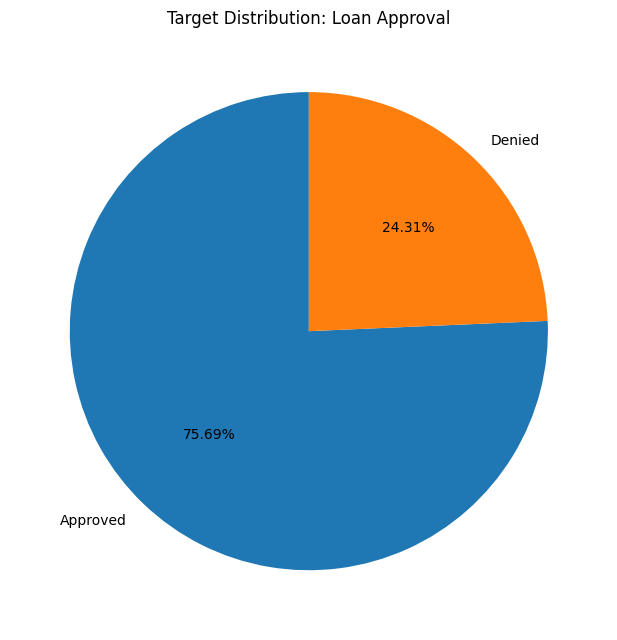

In [8]:
target_series = df[target_col].map(category_mapping["loan_approved"])
target_counts = target_series.value_counts()

plt.figure(figsize=(6.5, 6.5))

plt.pie(
    target_counts.values,
    labels=target_counts.index,
    autopct="%.2f%%",
    startangle=90,
    textprops={"fontsize": 10},
)

plt.title("Target Distribution: Loan Approval")
plt.tight_layout()
plt.show()

### 6. Missing value analysis

,feature,missing_count,missing_rate_percent
0,property_value,567755,6.57
1,income,544762,6.31
2,loan_term,410612,4.75
3,tract_to_msa_income_percentage,159649,1.85
4,county_code,87965,1.02
5,ffiec_msa_md_median_family_income,85791,0.99
6,state_code,45096,0.52
7,conforming_loan_limit,37695,0.44


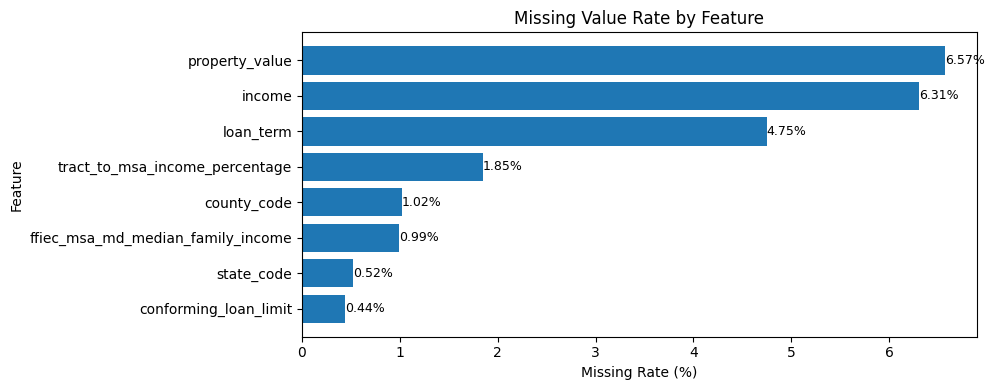

In [9]:
missing_summary = df.isna().sum().reset_index()
missing_summary.columns = ["feature", "missing_count"]

missing_summary["missing_rate_percent"] = (
    missing_summary["missing_count"] / len(df) * 100
).round(2)

missing_summary = (
    missing_summary[missing_summary["missing_count"] > 0]
    .sort_values("missing_rate_percent", ascending=False)
    .reset_index(drop=True)
)

display(missing_summary)

plt.figure(figsize=(10, max(4, len(missing_summary) * 0.35)))
plt.barh(
    missing_summary["feature"],
    missing_summary["missing_rate_percent"],
)

plt.xlabel("Missing Rate (%)")
plt.ylabel("Feature")
plt.title("Missing Value Rate by Feature")
plt.gca().invert_yaxis()

for i, value in enumerate(missing_summary["missing_rate_percent"]):
    plt.text(value, i, f"{value:.2f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### 7. Numeric feature summary

In [10]:
numeric_summary = (
    df[numeric_cols]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.95, 0.99])
    .T
    .round(2)
)

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,95%,99%,max
tract_median_age_of_housing_units,8636578.00,35.78,18.31,-1.00,23.00,35.00,48.00,67.00,76.00,80.00
tract_owner_occupied_units,8636578.00,1216.96,580.09,0.00,818.00,1168.00,1558.00,2210.00,2819.00,6276.00
tract_to_msa_income_percentage,8476929.00,110.50,39.58,2.00,84.00,105.00,130.00,182.00,240.00,516.00
ffiec_msa_md_median_family_income,8550787.00,100269.00,21439.73,23800.00,86400.00,98200.00,110000.00,143700.00,164200.00,201300.00
tract_minority_population_percent,8636578.00,36.22,25.88,0.00,15.36,28.93,52.27,89.92,98.08,100.00
tract_population,8636578.00,4756.90,2158.55,0.00,3406.00,4518.00,5820.00,8101.00,11725.00,30199.00
income,8091816.00,187.91,38773.56,-155317.00,67.00,104.00,164.00,363.00,813.00,100000000.00
property_value,8068823.00,557284.41,4301771.47,5000.00,255000.00,385000.00,595000.00,1255000.00,2615000.00,2147483647.00
loan_term,8225966.00,318.70,84.30,1.00,300.00,360.00,360.00,360.00,480.00,3292.00
loan_amount,8636578.00,297921.28,1937788.57,5000.00,95000.00,205000.00,355000.00,725000.00,1465000.00,2650005000.00


### 8. Main numeric distributions

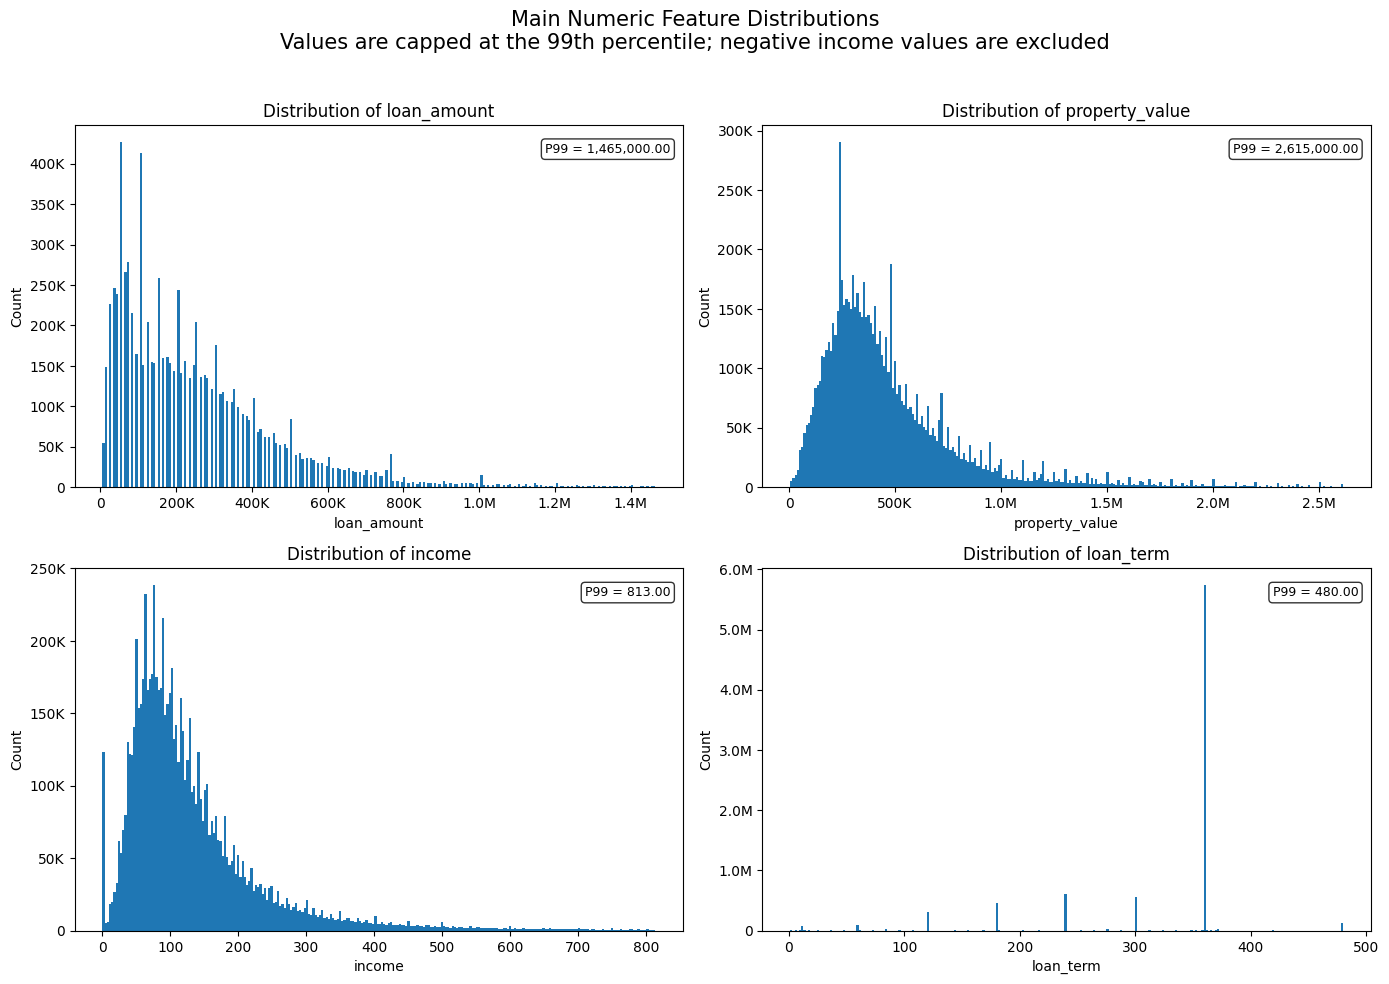

In [11]:
n_cols = 2
n_rows = math.ceil(len(main_numeric_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.8 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(main_numeric_features):
    data = df[col].dropna()

    # Income should not be negative for this EDA visualization
    if col == "income":
        data = data[data >= 0]

    upper = data.quantile(0.99)
    trimmed = data[data <= upper]

    axes[i].hist(trimmed, bins=250)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].xaxis.set_major_formatter(FuncFormatter(format_number))
    axes[i].yaxis.set_major_formatter(FuncFormatter(format_number))

    axes[i].text(
        0.98,
        0.95,
        f"P99 = {upper:,.2f}",
        transform=axes[i].transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

fig.suptitle(
    "Main Numeric Feature Distributions\nValues are capped at the 99th percentile; negative income values are excluded",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
plt.show()

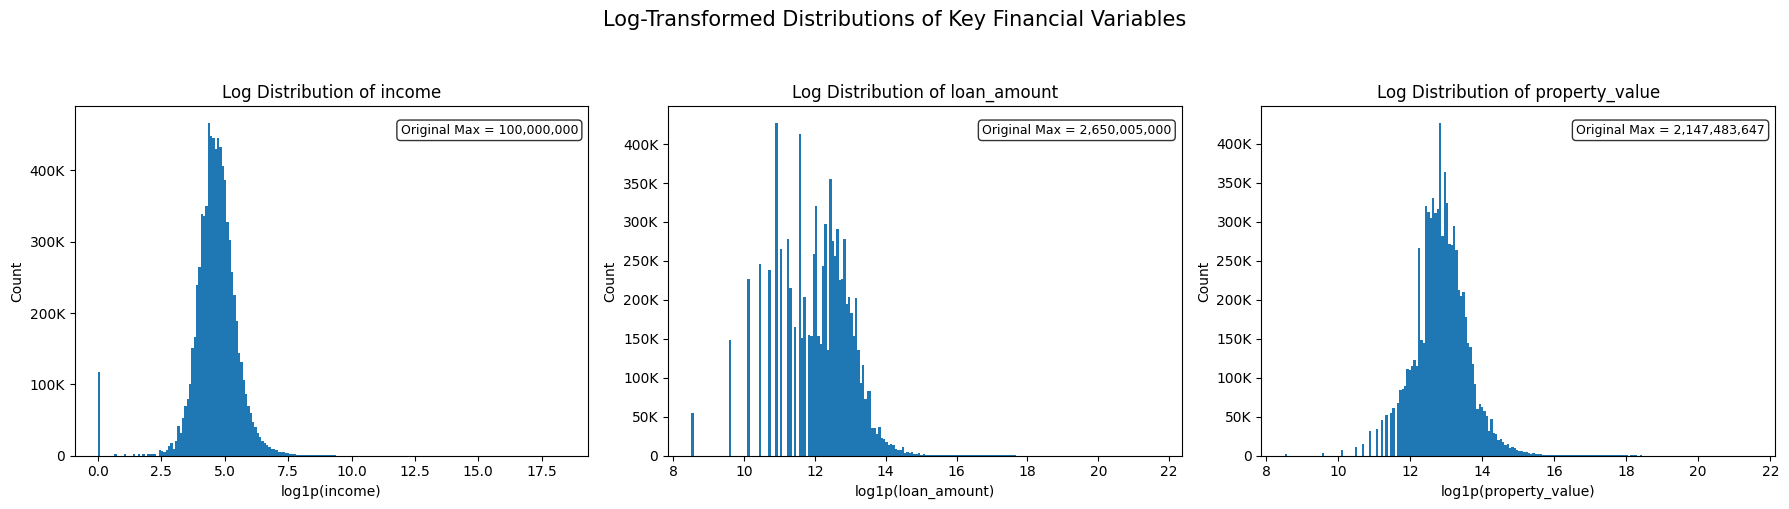

In [12]:
log_features = [
    "income",
    "loan_amount",
    "property_value"
]

n_cols = 3
n_rows = 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.8))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(log_features):
    data = pd.to_numeric(df[col], errors="coerce").dropna()

    # Log transform requires non-negative values
    data = data[data >= 0]

    log_data = np.log1p(data)

    axes[i].hist(log_data, bins=200)
    axes[i].set_title(f"Log Distribution of {col}")
    axes[i].set_xlabel(f"log1p({col})")
    axes[i].set_ylabel("Count")
    axes[i].yaxis.set_major_formatter(FuncFormatter(format_number))

    axes[i].text(
        0.98,
        0.95,
        f"Original Max = {data.max():,.0f}",
        transform=axes[i].transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

fig.suptitle(
    "Log-Transformed Distributions of Key Financial Variables",
    fontsize=15,
    y=1.05
)

plt.tight_layout()
plt.show()

### 9. Numeric features by approval status

In [13]:
numeric_approval_rows = []

for col in main_numeric_features:
    temp = df.groupby(target_col)[col].agg(["mean", "median"]).round(2)

    numeric_approval_rows.append({
        "feature": col,
        "denied_mean": temp.loc[0, "mean"],
        "denied_median": temp.loc[0, "median"],
        "approved_mean": temp.loc[1, "mean"],
        "approved_median": temp.loc[1, "median"],
    })

numeric_approval_summary = pd.DataFrame(numeric_approval_rows)

display(numeric_approval_summary)

,feature,denied_mean,denied_median,approved_mean,approved_median
0,loan_amount,211350.76,125000.00,325733.12,235000.00
1,property_value,512479.90,355000.00,570802.21,395000.00
2,income,227.38,80.00,174.87,113.00
3,loan_term,311.18,360.00,321.06,360.00


### 10. Boxplots: numeric features vs loan approval

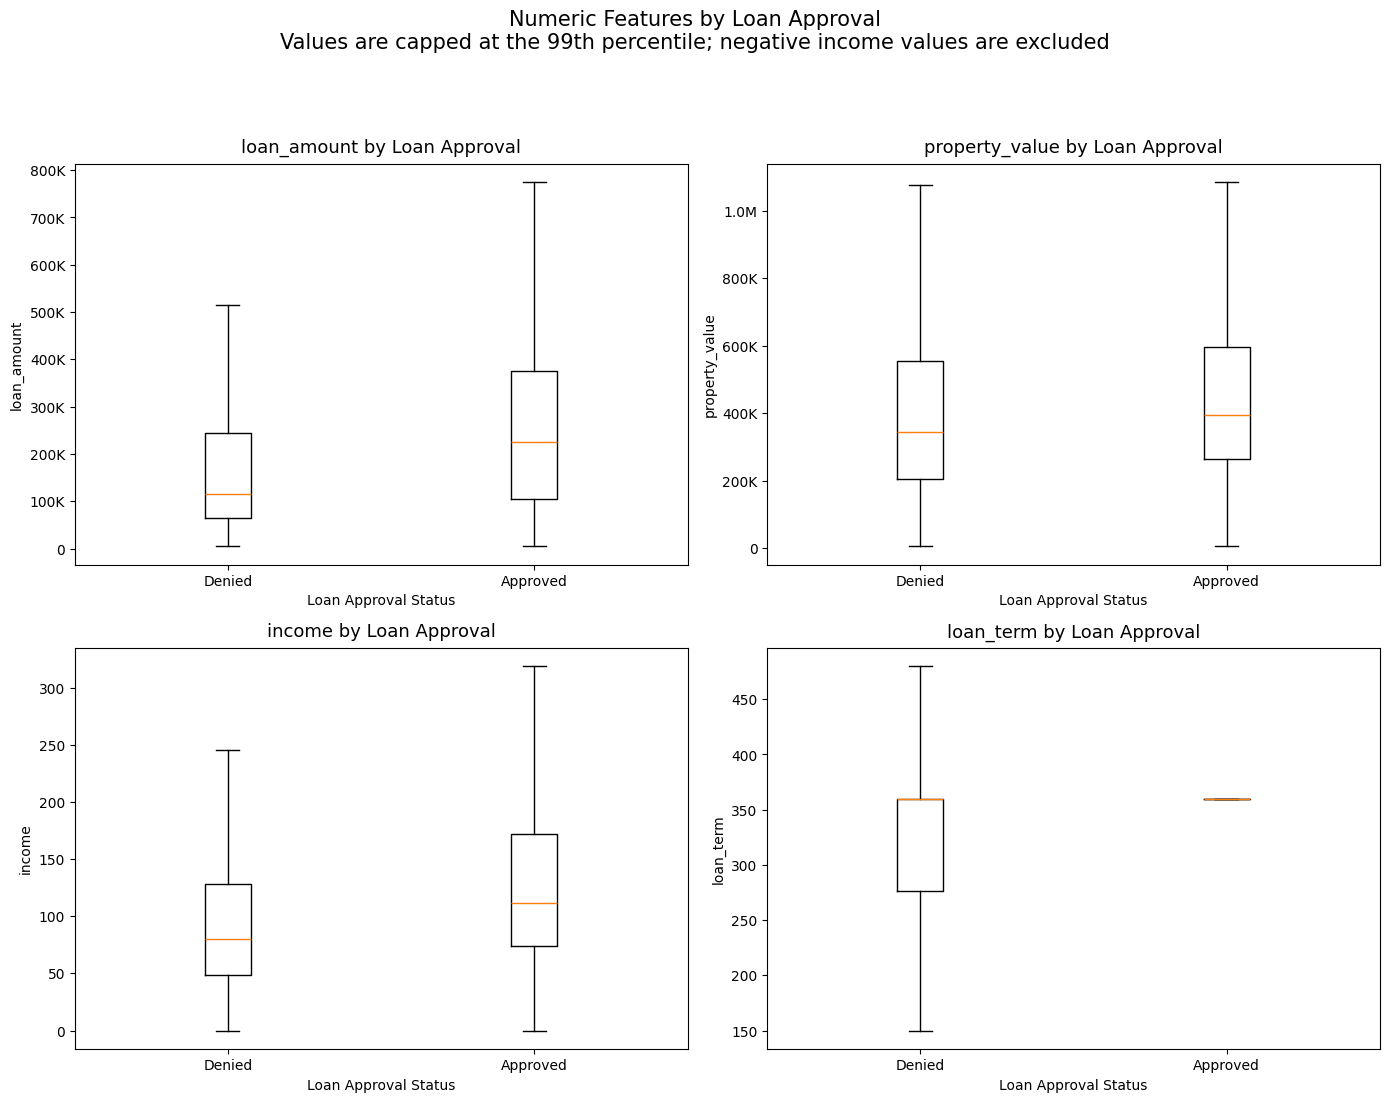

In [14]:
n_cols = 2
n_rows = math.ceil(len(main_numeric_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5.6 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(main_numeric_features):
    temp = df[[target_col, col]].dropna()

    if col == "income":
        temp = temp[temp[col] >= 0]

    upper = temp[col].quantile(0.99)
    temp = temp[temp[col] <= upper]

    denied_values = temp[temp[target_col] == 0][col]
    approved_values = temp[temp[target_col] == 1][col]

    axes[i].boxplot(
        [denied_values, approved_values],
        labels=["Denied", "Approved"],
        showfliers=False,
    )

    axes[i].set_title(f"{col} by Loan Approval", fontsize=13, pad=8)
    axes[i].set_xlabel("Loan Approval Status")
    axes[i].set_ylabel(col)
    axes[i].yaxis.set_major_formatter(FuncFormatter(format_number))

fig.suptitle(
    "Numeric Features by Loan Approval\n"
    "Values are capped at the 99th percentile; negative income values are excluded",
    fontsize=15,
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### 11. Categorical feature distributions

In [15]:
for col in main_categorical_features:
    temp = df[col].value_counts(dropna=False).reset_index()
    temp.columns = [col, "count"]

    temp["percentage"] = (temp["count"] / len(df) * 100).round(2)
    temp["label"] = temp[col].apply(lambda x: get_category_label(col, x))

    temp = temp[["label", "count", "percentage"]]

    print(f"\nDistribution of {col}:")
    display(temp)


Distribution of applicant_age:


,label,count,percentage
0,35-44,2050766,23.75
1,45-54,1789595,20.72
2,25-34,1685132,19.51
3,55-64,1407038,16.29
4,65-74,825255,9.56
5,>74,345730,4.00
6,<25,305678,3.54
7,Not_applicable,227384,2.63



Distribution of loan_purpose:


,label,count,percentage
0,1: Home purchase,4299553,49.78
1,32: Cash-out refinancing,1209290,14.00
2,4: Other purpose,1133581,13.13
3,2: Home improvement,1016550,11.77
4,31: Refinancing,974136,11.28
5,5: Not applicable,3468,0.04



Distribution of has_co_applicant:


,label,count,percentage
0,0: No co-applicant,5055347,58.53
1,1: Has co-applicant,3581231,41.47



Distribution of conforming_loan_limit:


,label,count,percentage
0,C: Conforming,8355800,96.75
1,NC: Non-conforming,242060,2.80
2,nan,37695,0.44
3,U: Undetermined,1023,0.01


### 12. Approval rate vs categorical variables

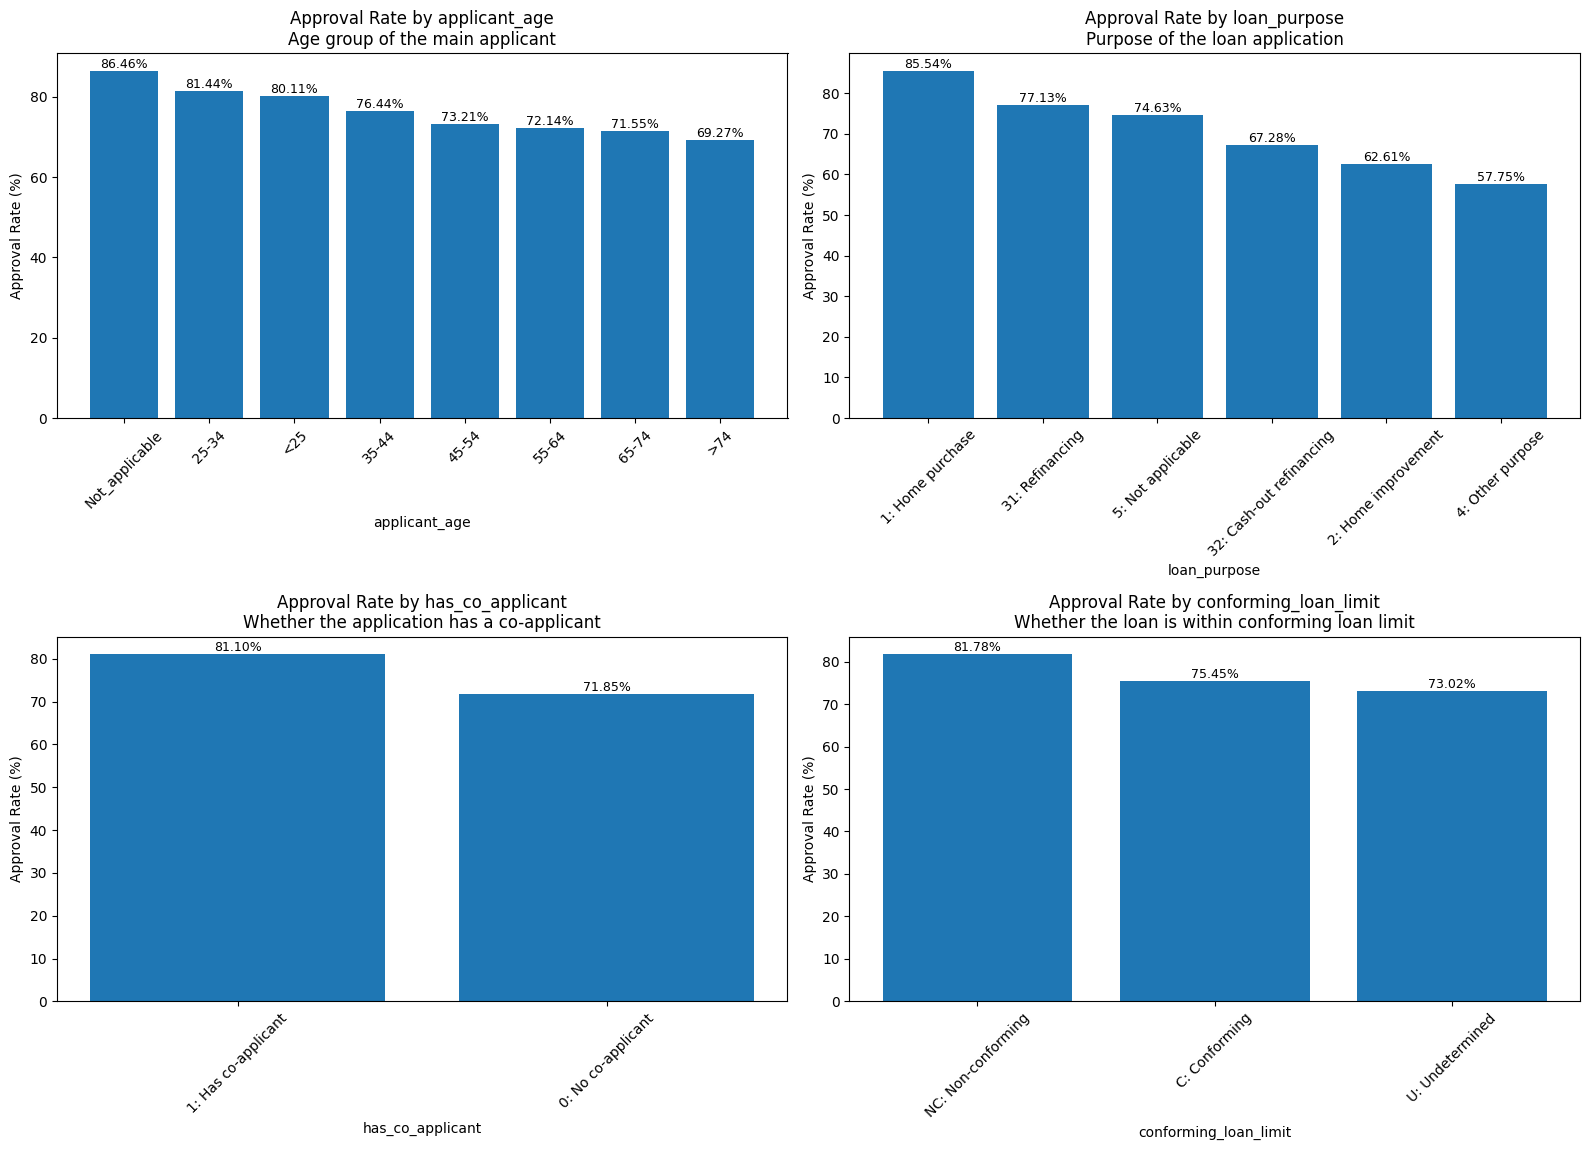

In [16]:
n_cols = 2
n_rows = math.ceil(len(main_categorical_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5.8 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(main_categorical_features):
    temp = df[[col, target_col]].dropna().copy()

    approval_rate = (
        temp.groupby(col)[target_col]
        .mean()
        .sort_values(ascending=False)
        * 100
    ).round(2)

    x_labels = [get_category_label(col, x) for x in approval_rate.index]

    axes[i].bar(x_labels, approval_rate.values)

    axes[i].set_title(f"Approval Rate by {col}\n{feature_meaning.get(col, '')}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Approval Rate (%)")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].yaxis.set_major_formatter(FuncFormatter(format_number))

    add_bar_labels(axes[i], approval_rate.values, suffix="%", decimals=2)

plt.tight_layout()
plt.show()

### 13. has_co_applicant pie chart

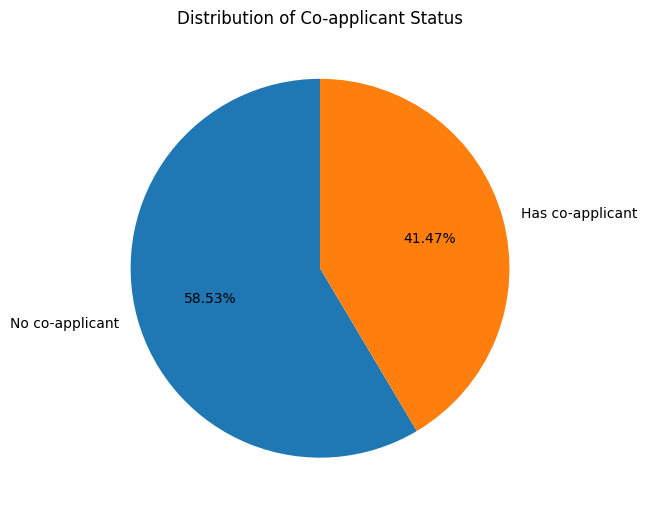

In [17]:
co_series = df["has_co_applicant"].map(category_mapping["has_co_applicant"])
co_counts = co_series.value_counts()

plt.figure(figsize=(6.5, 6.5))

plt.pie(
    co_counts.values,
    labels=co_counts.index,
    autopct="%.2f%%",
    startangle=90,
    textprops={"fontsize": 10},
)

plt.title("Distribution of Co-applicant Status")
plt.tight_layout()
plt.show()

### 14. Correlation heatmap with values

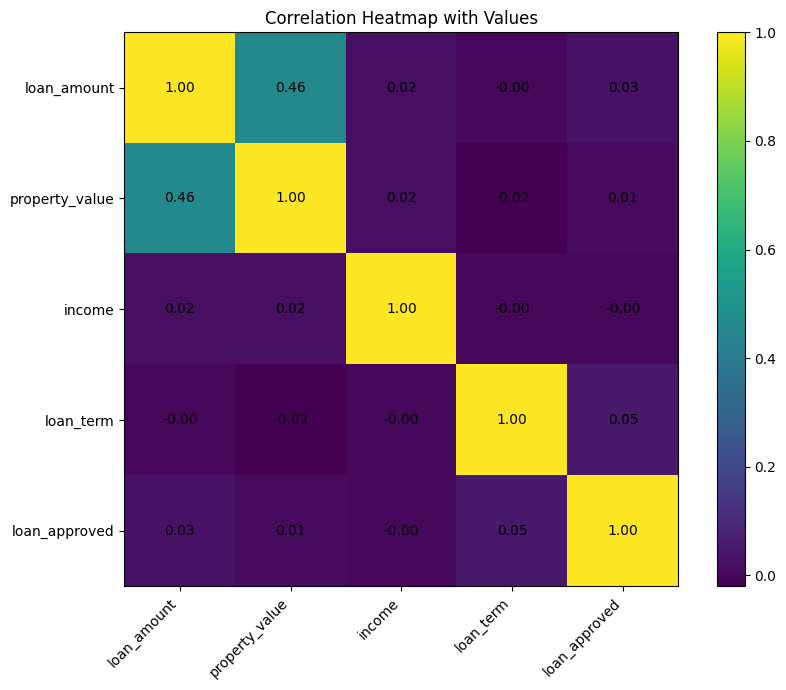

In [18]:
corr_cols = main_numeric_features + [target_col]
corr = df[corr_cols].corr(numeric_only=True).round(2)

fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(corr)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

for row in range(len(corr.columns)):
    for col in range(len(corr.columns)):
        ax.text(
            col,
            row,
            f"{corr.iloc[row, col]:.2f}",
            ha="center",
            va="center",
            fontsize=10,
        )

plt.colorbar(im)
plt.title("Correlation Heatmap with Values")
plt.tight_layout()
plt.show()

### 15. Zero value check for numeric columns

In [19]:
zero_summary_rows = []

for col in numeric_cols:
    zero_count = (df[col] == 0).sum()
    non_missing_count = df[col].notna().sum()

    zero_summary_rows.append({
        "feature": col,
        "zero_count": zero_count,
        "zero_rate_all_rows_percent": round(zero_count / len(df) * 100, 2),
        "zero_rate_non_missing_percent": round(
            zero_count / non_missing_count * 100, 2
        ) if non_missing_count > 0 else np.nan,
    })

zero_summary = pd.DataFrame(zero_summary_rows)
zero_summary = zero_summary.sort_values("zero_count", ascending=False)

display(zero_summary)

,feature,zero_count,zero_rate_all_rows_percent,zero_rate_non_missing_percent
0,tract_median_age_of_housing_units,481939,5.58,5.58
1,tract_owner_occupied_units,121055,1.40,1.40
4,tract_minority_population_percent,119171,1.38,1.38
5,tract_population,119005,1.38,1.38
6,income,116658,1.35,1.44
2,tract_to_msa_income_percentage,0,0.00,0.00
3,ffiec_msa_md_median_family_income,0,0.00,0.00
7,property_value,0,0.00,0.00
8,loan_term,0,0.00,0.00
9,loan_amount,0,0.00,0.00


### 16. Outlier and numeric quality check

In [20]:
outlier_check_rows = []

for col in numeric_cols:
    data = df[col].dropna()

    negative_count = (data < 0).sum()

    outlier_check_rows.append({
        "feature": col,
        "negative_count": int(negative_count),
        "negative_rate_percent": round(negative_count / len(data) * 100, 2),
        "median": round(data.median(), 2),
        "p95": round(data.quantile(0.95), 2),
        "p99": round(data.quantile(0.99), 2),
        "max": round(data.max(), 2),
    })

outlier_check = pd.DataFrame(outlier_check_rows)
outlier_check = outlier_check.sort_values("p99", ascending=False)

display(outlier_check)

,feature,negative_count,negative_rate_percent,median,p95,p99,max
7,property_value,0,0.00,385000.00,1255000.00,2615000.00,2147483647.00
9,loan_amount,0,0.00,205000.00,725000.00,1465000.00,2650005000.00
3,ffiec_msa_md_median_family_income,0,0.00,98200.00,143700.00,164200.00,201300.00
5,tract_population,0,0.00,4518.00,8101.00,11725.00,30199.00
1,tract_owner_occupied_units,0,0.00,1168.00,2210.00,2819.00,6276.00
6,income,7213,0.09,104.00,363.00,813.00,100000000.00
8,loan_term,0,0.00,360.00,360.00,480.00,3292.00
2,tract_to_msa_income_percentage,0,0.00,105.00,182.00,240.00,516.00
4,tract_minority_population_percent,0,0.00,28.93,89.92,98.08,100.00
0,tract_median_age_of_housing_units,161,0.00,35.00,67.00,76.00,80.00


In [21]:
categorical_cols_to_check = [
    "co_applicant_credit_score_type",
    "applicant_credit_score_type",
    "co_applicant_age",
    "applicant_age",
    "loan_purpose",
    "loan_type",
    "occupancy_type",
    "reverse_mortgage",
    "business_or_commercial_purpose",
    "open_end_line_of_credit",
    "conforming_loan_limit",
    "lien_status",
    "preapproval",
    "has_co_applicant",
]



### 17. Categorical value distribution check

In [22]:
def get_category_label(col, value):
    """
    Convert category code to readable label.
    Only return the meaning, not the value itself.
    """
    mapping = category_mapping.get(col, {})

    if value in mapping:
        return mapping[value]

    value_str = str(value)

    for key, label in mapping.items():
        if str(key) == value_str:
            return label

    return np.nan

In [23]:
for col in categorical_cols_to_check:
    temp = df[col].value_counts(dropna=False).reset_index()
    temp.columns = ["value", "count"]

    temp["percentage"] = (
        temp["count"] / len(df) * 100
    ).round(2)

    # Age columns are already readable, so no label column is needed
    if col in ["applicant_age", "co_applicant_age"]:
        temp = temp[["value", "count", "percentage"]]

    else:
        temp["label"] = temp["value"].apply(
            lambda x: get_category_label(col, x)
        )

        # If no useful label exists, do not keep a repeated/empty label column
        if temp["label"].notna().any():
            temp = temp[["value", "label", "count", "percentage"]]
        else:
            temp = temp[["value", "count", "percentage"]]

    print(f"\nCategorical value distribution: {col}")
    display(temp)


Categorical value distribution: co_applicant_credit_score_type


,value,label,count,percentage
0,No_co_applicant,No co-applicant,4893969,56.67
1,9,Not applicable,1781734,20.63
2,1,Equifax Beacon 5.0,472601,5.47
3,2,Experian Fair Isaac Risk Model v2,393731,4.56
4,3,TransUnion FICO Risk Score Classic 04,392069,4.54
5,Exempt,Exempt,249026,2.88
6,8,Other credit scoring model,152406,1.76
7,11,NaN,103124,1.19
8,7,More than one credit scoring model,70750,0.82
9,12,NaN,53933,0.62



Categorical value distribution: applicant_credit_score_type


,value,label,count,percentage
0,1,Equifax Beacon 5.0,2161337,25.03
1,2,Experian Fair Isaac Risk Model v2,1778892,20.60
2,3,TransUnion FICO Risk Score Classic 04,1769007,20.48
3,9,Not applicable,1047380,12.13
4,8,Other credit scoring model,559270,6.48
5,11,NaN,403657,4.67
6,Exempt,Exempt,249026,2.88
7,7,More than one credit scoring model,234758,2.72
8,12,NaN,220477,2.55
9,15,NaN,93178,1.08



Categorical value distribution: co_applicant_age


...

,value,label,count,percentage
0,1,Secured by first lien,6255567,72.43
1,2,Secured by subordinate lien,2381011,27.57



Categorical value distribution: preapproval


,value,label,count,percentage
0,2,Preapproval not requested,8439475,97.72
1,1,Preapproval requested,197103,2.28



Categorical value distribution: has_co_applicant


,value,label,count,percentage
0,0,No co-applicant,5055347,58.53
1,1,Has co-applicant,3581231,41.47
